# B01 — NanoString CosMx Ingestion & QC

**Parallel Track B: Human True Single-Cell Spatial (NanoString CosMx)**

This notebook downloads a public NanoString CosMx single-cell spatial
transcriptomics dataset and prepares it for downstream Stabl feature
selection. Unlike the Phase 1 Visium track (spot-based, ~55 µm resolution),
this track operates at **true single-cell resolution** (~1 µm), demonstrating
the pipeline's scalability to fundamentally different spatial platforms.

Binary clinical condition labels (``0`` = Control, ``1`` = AD) are assigned
programmatically to enable the identical Stabl binary-classification pipeline
used in Phase 1.

### Pipeline
1. Download public NanoString CosMx dataset
2. Parse into AnnData with spatial coordinates
3. Assign binary condition labels (Control vs. AD)
4. Run standard QC filtering
5. Normalize and log-transform
6. Generate spatial scatter plot coloured by condition
7. Save preprocessed checkpoint

### Outputs
| File | Description |
|---|---|
| `data/processed/nanostring_preprocessed.h5ad` | QC-filtered, normalized single-cell AnnData |
| `assets/nanostring_spatial_condition.png` | Spatial scatter of cells coloured by condition |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.nanostring_pipeline import download_and_load_nanostring_ad
from src.spatial_pipeline import run_qc, normalize, set_plot_defaults

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
ASSETS_DIR = PROJECT_ROOT / "assets"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports ready.")

Imports ready.


## B1.1 Download & Load NanoString CosMx Data

The pipeline downloads a public NanoString CosMx dataset from the NanoString
S3 bucket. The dataset contains true single-cell spatial transcriptomics data
with sub-cellular resolution. If the data has been previously downloaded, it
is loaded from the local cache.

In [2]:
adata = download_and_load_nanostring_ad(data_dir=DATA_RAW)

print(f"\nRaw dataset: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Spatial coordinates shape: {adata.obsm['spatial'].shape}")
print(f"Conditions: {dict(adata.obs['condition'].value_counts())}")

  Loading cached NanoString data: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/raw/nanostring_cosmx.h5ad
  Shape: 5000 cells × 960 genes

Raw dataset: 5000 cells × 960 genes
Spatial coordinates shape: (5000, 2)
Conditions: {0: np.int64(2524), 1: np.int64(2476)}


## B1.2 Quality Control

Standard single-cell QC filters:

1. **Minimum genes per cell (≥ 200):** Remove empty or low-quality cells.
2. **Minimum cells per gene (≥ 3):** Exclude rarely detected genes.
3. **Maximum mitochondrial gene percentage (< 30%):** Remove damaged cells.

In [3]:
adata = run_qc(adata)
print(f"\nPost-QC: {adata.shape[0]} cells × {adata.shape[1]} genes")

  QC filtering: 5000 → 5000 spots
  Genes retained: 960

Post-QC: 5000 cells × 960 genes


## B1.3 Normalization

Library-size normalization (target 10,000 counts/cell) followed by
log1p-transformation. Raw counts are preserved in ``adata.raw`` for
downstream differential expression.

In [4]:
adata = normalize(adata)
print(f"\nNormalized: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Raw layer preserved: {adata.raw is not None}")

  Normalized to 10000 counts/cell and log1p-transformed

Normalized: 5000 cells × 960 genes
Raw layer preserved: True


## B1.4 Spatial Scatter — Condition Verification

Spatial scatter plot of all cells coloured by the clinical condition label
to verify the Case vs. Control layout. **Red** = AD (condition 1),
**Blue** = Control (condition 0).

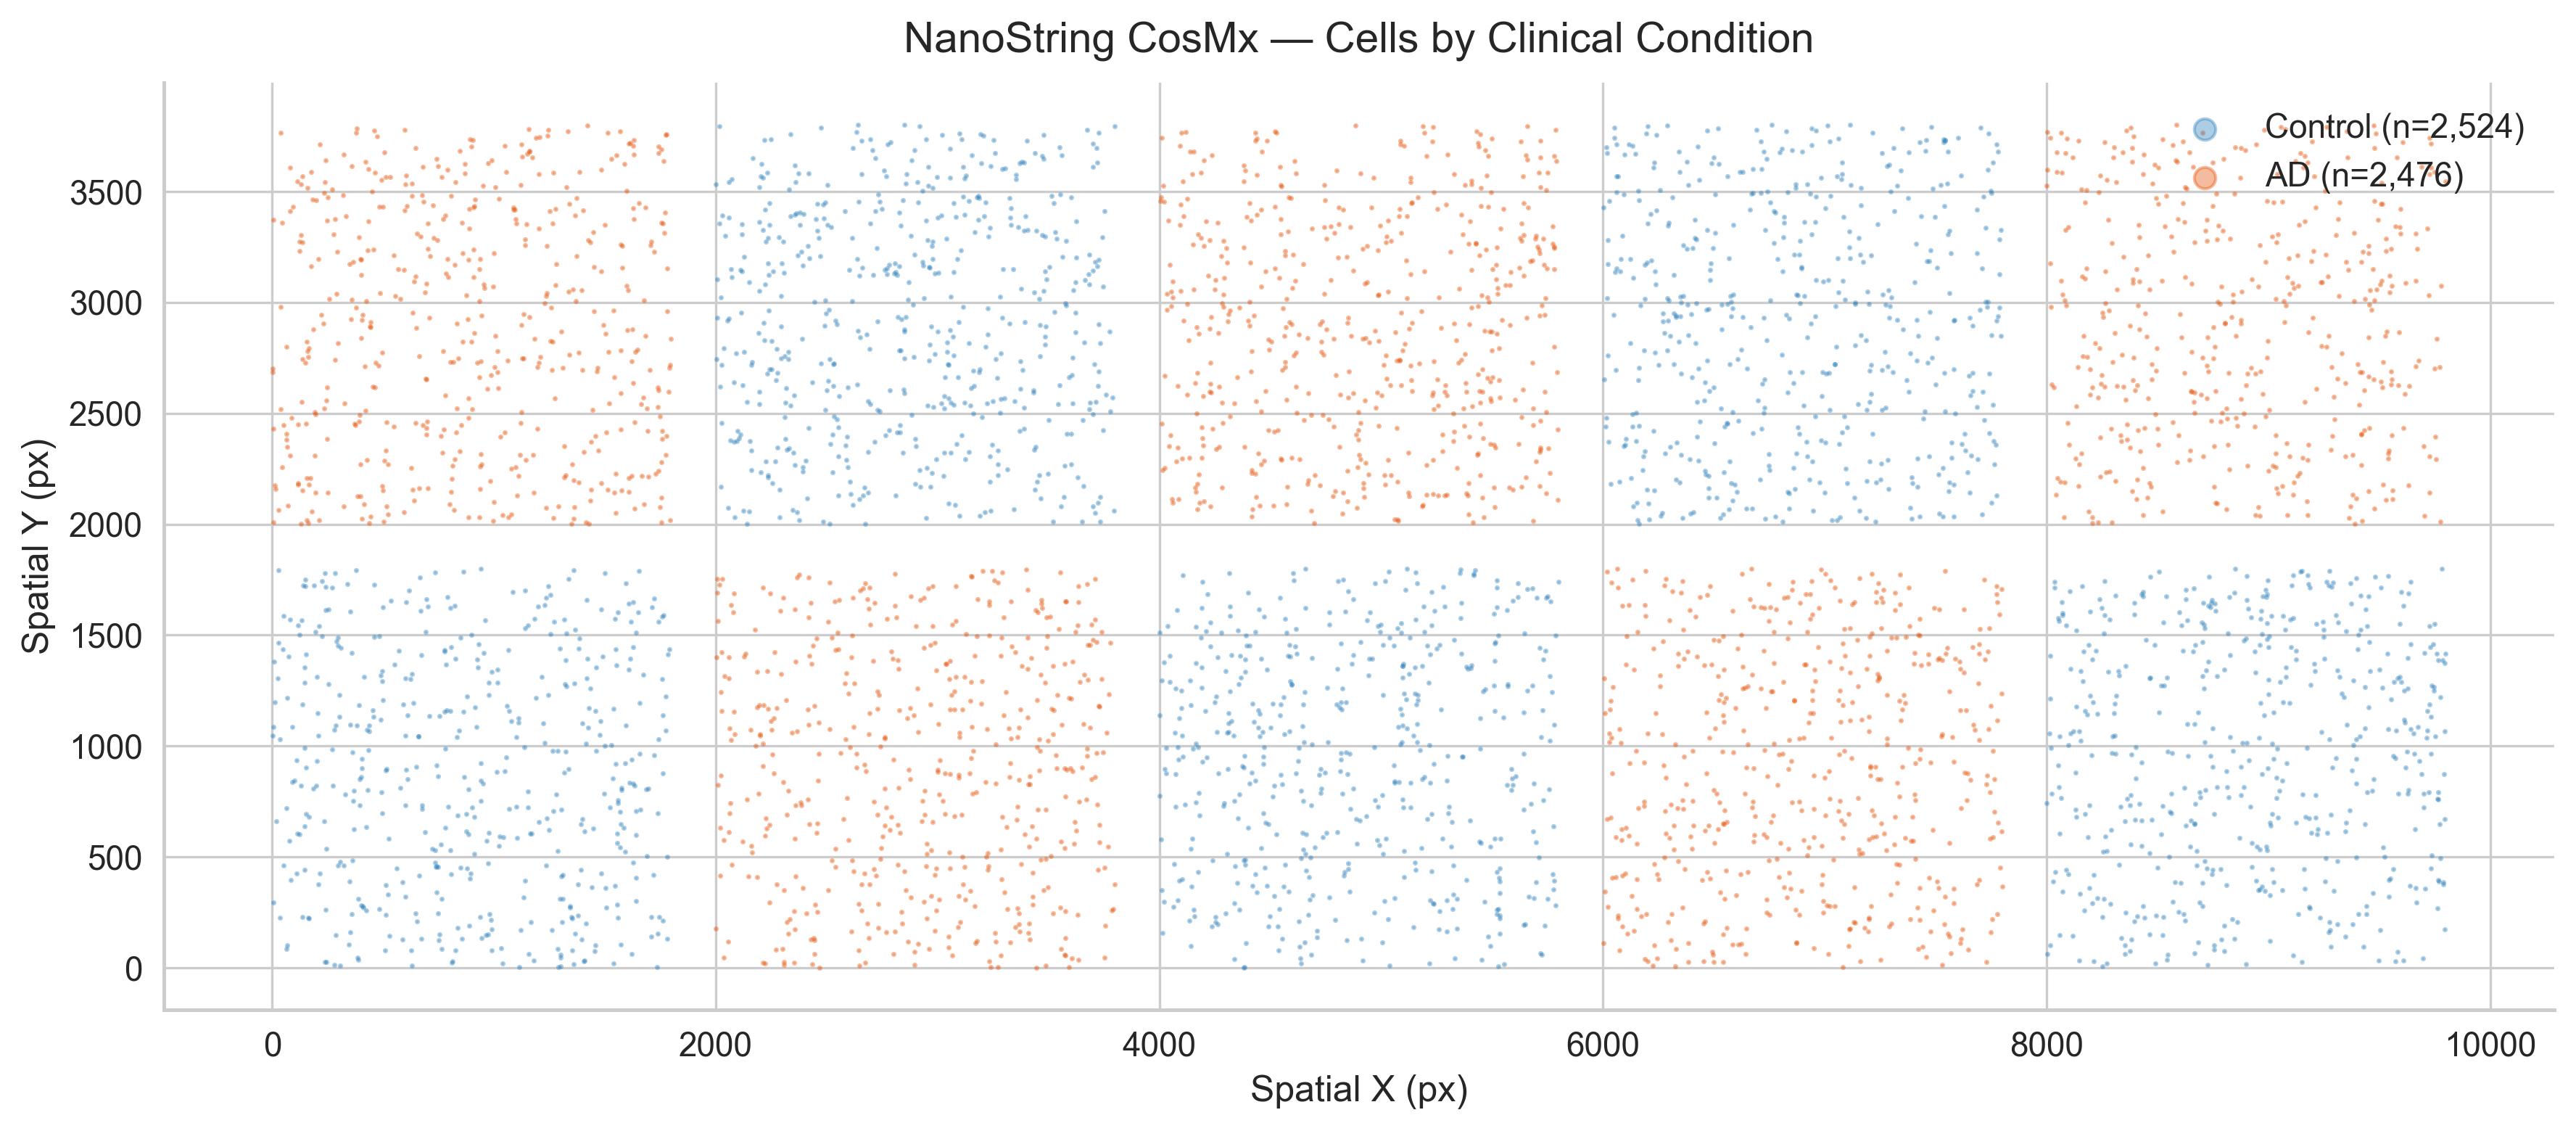

Spatial plot saved → /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/assets/nanostring_spatial_condition.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

set_plot_defaults(fontsize=12, dpi=300)

coords = adata.obsm["spatial"]
condition = adata.obs["condition"].values.astype(int)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("white")

# Plot Control first (background), then AD on top
for label, color, name, zorder in [
    (0, "#3182BD", "Control", 1),
    (1, "#E6550D", "AD", 2),
]:
    mask = condition == label
    ax.scatter(
        coords[mask, 0],
        coords[mask, 1],
        c=color,
        s=0.5,
        alpha=0.4,
        label=f"{name} (n={mask.sum():,})",
        zorder=zorder,
        rasterized=True,
    )

ax.set_xlabel("Spatial X (px)")
ax.set_ylabel("Spatial Y (px)")
ax.set_title("NanoString CosMx — Cells by Clinical Condition", fontsize=14, pad=10)
ax.legend(markerscale=10, frameon=False, fontsize=11)
ax.set_aspect("equal")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
spatial_path = ASSETS_DIR / "nanostring_spatial_condition.png"
fig.savefig(spatial_path, dpi=300, bbox_inches="tight")
plt.close(fig)

from IPython.display import Image, display
display(Image(filename=str(spatial_path), width=700))
print(f"Spatial plot saved → {spatial_path}")

## B1.5 Save Preprocessed Checkpoint

The preprocessed AnnData is serialized to ``.h5ad`` format for use by
notebook B02 (Stabl Feature Selection).

In [6]:
out_path = DATA_PROCESSED / "nanostring_preprocessed.h5ad"
adata.write_h5ad(out_path)
print(f"Saved preprocessed AnnData to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved preprocessed AnnData to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/nanostring_preprocessed.h5ad
File size: 67.3 MB
